In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Period

In [2]:
iyear = 1960
fyear = 2025
models = ['ERA5']
domains = ['HMA','HK','SL','TP','CH','SEH']

# TP DATASETS

In [4]:
tp_datasets = {}

files = {
    'ERA5': 'vimd_monthly_era5_1940-2025_NH_025x025.nc'
}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/'

for model in models:
    tp_datasets[model] = {}
    tp_model = xr.open_dataset(path + files[model])['vimd']

    tp_model=tp_model.rename({'valid_time': 'time'})
    tp_model=tp_model.rename({'longitude': 'lon'})
    tp_model=tp_model.rename({'latitude': 'lat'})
    
    tp_model=tp_model.sel(time=slice(str(iyear),str(fyear)))

    for domain in domains:
        tp_datasets[model][domain] = field_dom(tp_model,domain)

# MONTHLY SELECTION DATASETS DOMAINS

In [5]:
tp_month_dict = {}

for model in models:
    tp_month_dict[model]={}
    print(model)
    for domain in domains:
        tp_month_dict[model][domain] = tp_datasets[model][domain].groupby('time.month')
        tp_month_dict[model][domain] = tp_month_dict[model][domain].mean(dim=['lat','lon'], skipna=True)
        print(domain)


ERA5
HMA
HK
SL
TP
CH
SEH


In [6]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

tp_trend_dict = {}

for model in models:
    tp_trend_dict[model]={}
    print(model)
    for domain in domains:
        tp_trend_dict[model][domain]={}
        print(domain)
        for i, mo in enumerate(months):
            da_m = tp_month_dict[model][domain].where(
                tp_month_dict[model][domain].time.dt.month == i+1,
                drop=True
            )
            
            tp_trend_dict[model][domain][mo] = stats.linregress(
                da_m.time.dt.year.values,
                da_m.values
            )            
            print(mo)

ERA5
HMA
Jan
Feb
Mar
Apr
May
Jun
Jul
Aug
Sep
Oct
Nov
Dec
HK
Jan
Feb
Mar
Apr
May
Jun
Jul
Aug
Sep
Oct
Nov
Dec
SL
Jan
Feb
Mar
Apr
May
Jun
Jul
Aug
Sep
Oct
Nov
Dec
TP
Jan
Feb
Mar
Apr
May
Jun
Jul
Aug
Sep
Oct
Nov
Dec
CH
Jan
Feb
Mar
Apr
May
Jun
Jul
Aug
Sep
Oct
Nov
Dec
SEH
Jan
Feb
Mar
Apr
May
Jun
Jul
Aug
Sep
Oct
Nov
Dec


In [7]:
tp_slope_dict = {}

for model in models:
    tp_slope_dict[model] = {}
    
    for dom in domains:
        slopes = []
        
        for mon in months:
            # récupère uniquement la slope
            slope_val = tp_trend_dict[model][dom][mon].slope * 10 # slope & mm/month/year --> mm/month/decade
            slopes.append(slope_val)
        
        # on transforme en DataArray pour garder la même logique que ton code
        tp_slope_dict[model][dom] = xr.DataArray(
            slopes,
            coords={'month': np.arange(1, 13)},
            dims=['month']
        )

In [8]:
tp_pvalue_dict = {}

for model in models:
    tp_pvalue_dict[model] = {}
    
    for dom in domains:
        pvalues = []
        
        for mon in months:
            # récupère uniquement la slope
            pvalue_val = tp_trend_dict[model][dom][mon].pvalue
            pvalues.append(pvalue_val)
        
        # on transforme en DataArray pour garder la même logique que ton code
        tp_pvalue_dict[model][dom] = xr.DataArray(
            pvalues,
            coords={'month': np.arange(1, 13)},
            dims=['month']
        )

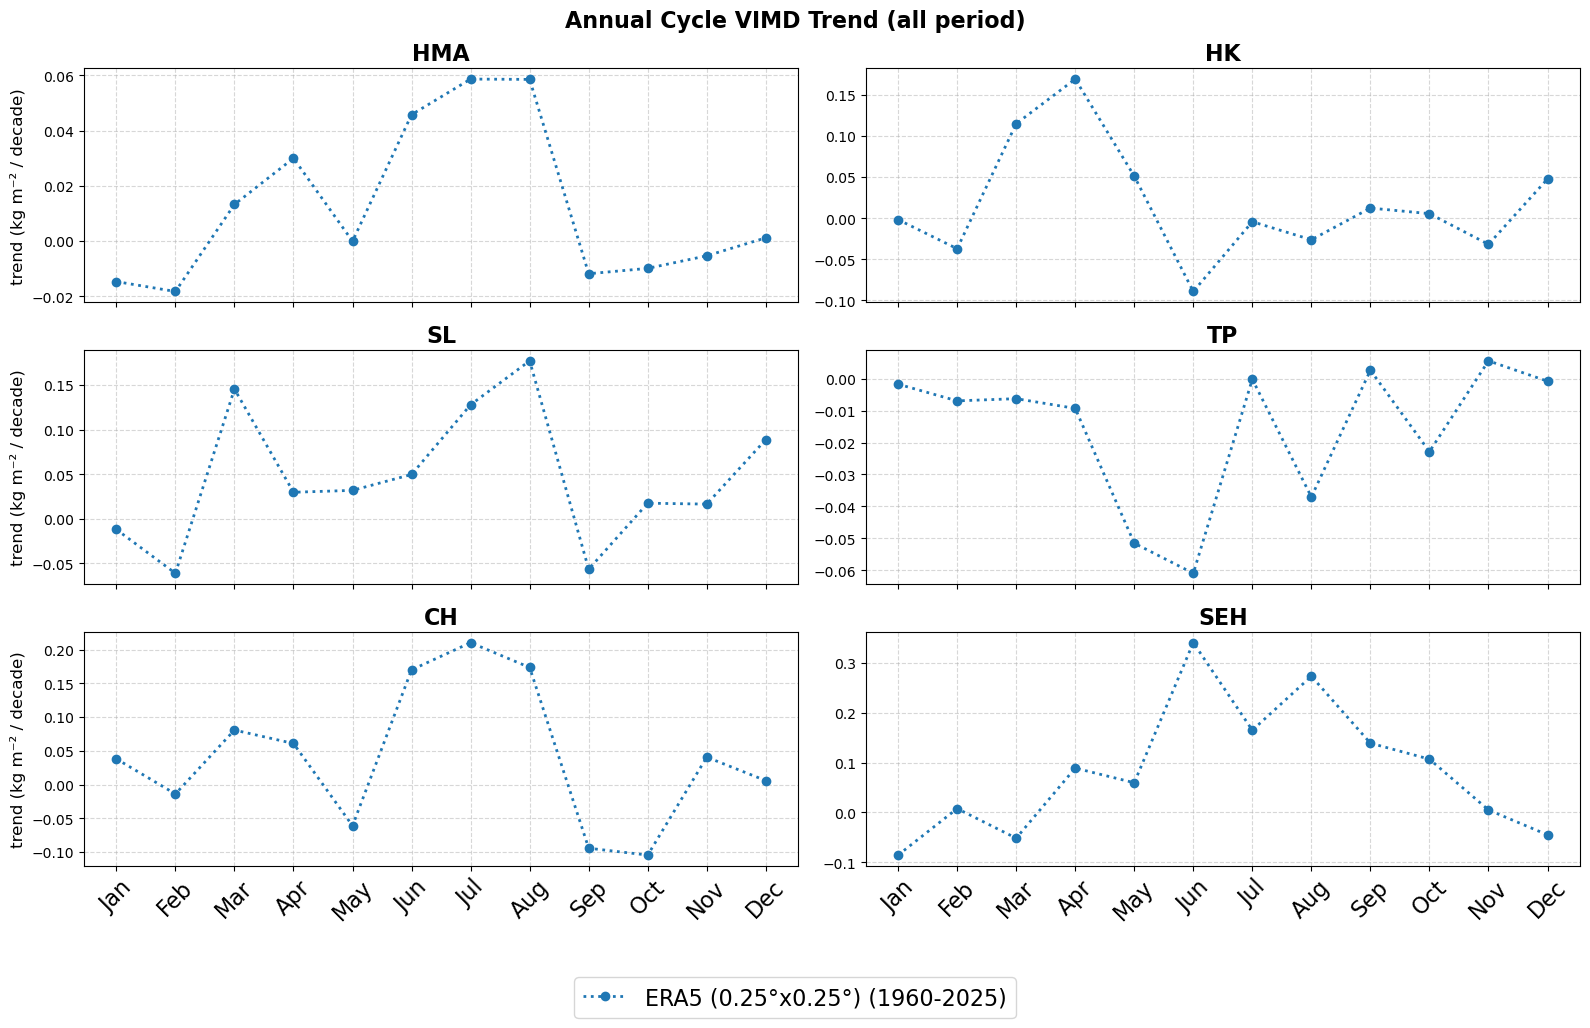

In [9]:
periods = {'ERA5': '1960-2025'}

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
resolutions = {'ERA5': '0.25°x0.25°'}
colors = {'ERA5': 'brown'}

fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

for i, dom in enumerate(domains):

    ax = axes[i]

    for model in models:
        da = tp_slope_dict[model][dom]
        ax.plot(da['month'], da.values, marker='o', linestyle=':', label=f'{model} ({resolutions[model]}) ({periods[model]})', linewidth=2)

    ax.set_title(dom, fontsize=16, weight="bold")
    ax.set_xticks(range(1,13))
    
    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('trend (kg m⁻² / decade)', fontsize=12)
    if i in [4, 5]:  # ligne du bas
        ax.set_xticklabels(months, rotation=45, fontsize=16)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'Annual Cycle VIMD Trend (all period)', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

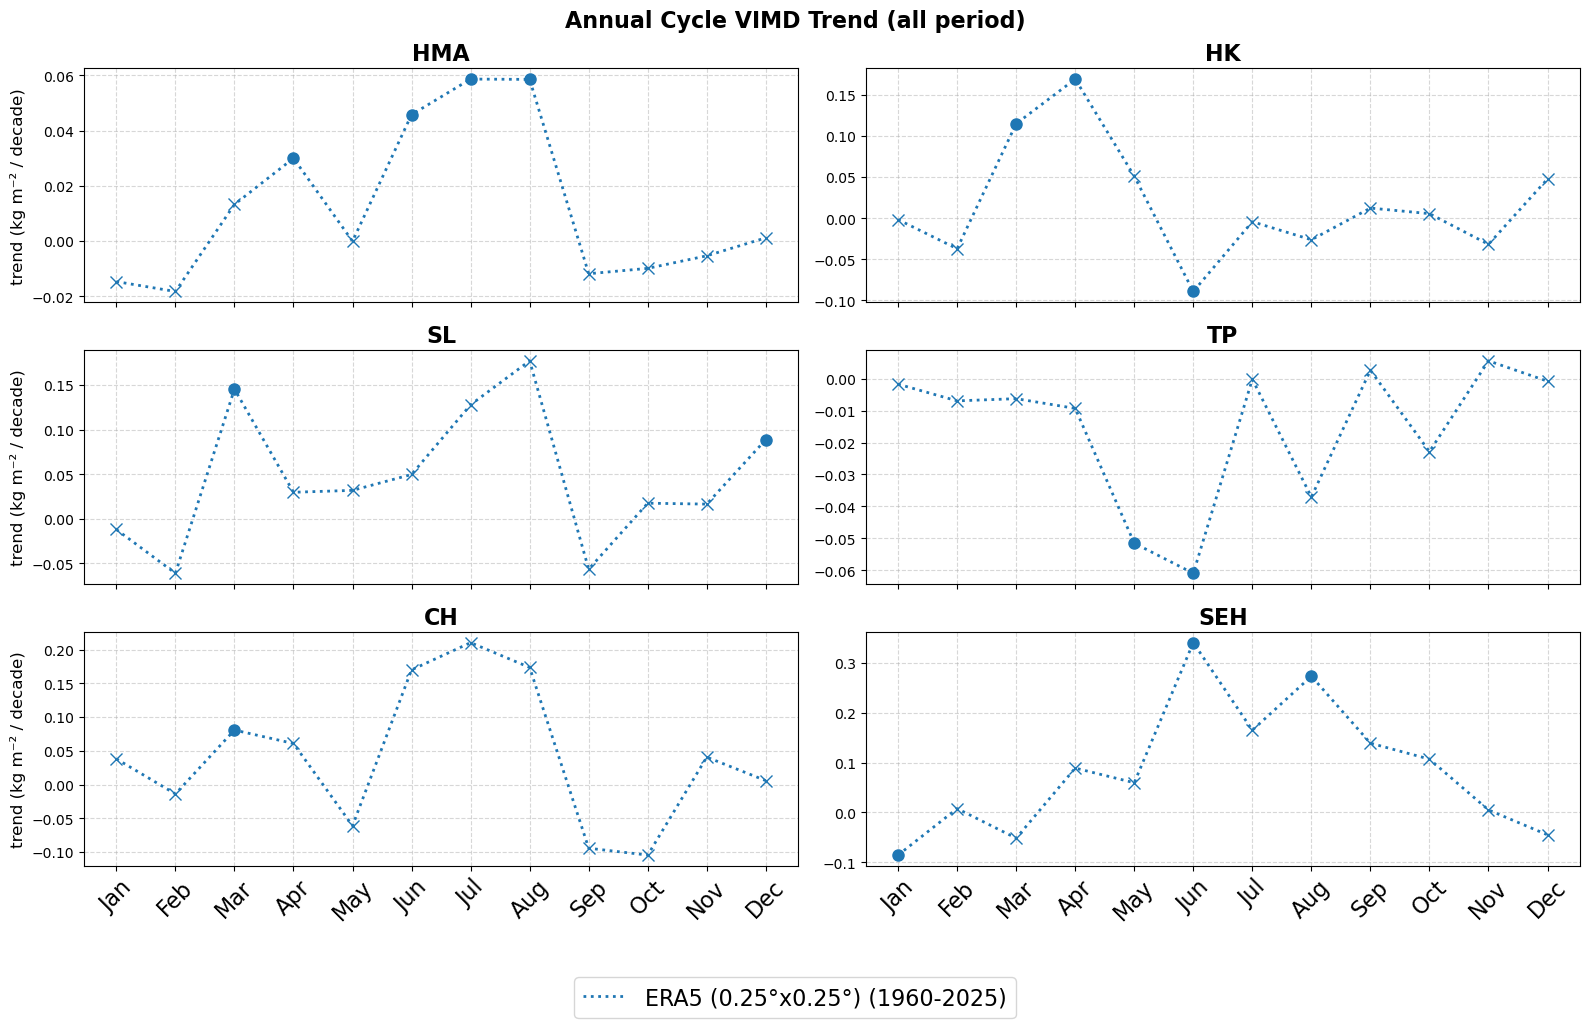

In [10]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
resolutions = {'ERA5': '0.25°x0.25°'}

# Extraire les couleurs Tableau (ordre stable)
tableau_colors = list(mcolors.TABLEAU_COLORS.values())

# Assigner une couleur par modèle dans l'ordre
model_colors = {model: tableau_colors[i % len(tableau_colors)] for i, model in enumerate(models)}

fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

for i, dom in enumerate(domains):
    ax = axes[i]

    for model in models:
        slopes = tp_slope_dict[model][dom].values
        pvalues = tp_pvalue_dict[model][dom].values
        
        # Créer liste de markers pour chaque mois selon pvalue
        markers = ['x' if p>0.05 else 'o' for p in pvalues]

        # Tracer la ligne en utilisant la couleur automatique et linestyle
        ax.plot(range(1,13), slopes, linestyle=':', linewidth=2, label=f'{model} ({resolutions[model]}) ({periods[model]})',
               color=model_colors[model])
        
        # Ajouter les markers au-dessus de la ligne
        for m_idx, month_num in enumerate(range(1,13)):
            ax.plot(month_num, slopes[m_idx], marker=markers[m_idx], linestyle='None', markersize=8,
                   color=model_colors[model])

    ax.set_title(dom, fontsize=16, weight="bold")
    ax.set_xticks(range(1,13))
    
    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('trend (kg m⁻² / decade)', fontsize=12)
    if i in [4, 5]:  # ligne du bas
        ax.set_xticklabels(months, rotation=45, fontsize=16)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'Annual Cycle VIMD Trend (all period)', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()